# Hospitalizaciones y defunciones semnales

## Filtrado de los datos

In [2]:
# Importamos las librerias necesarias
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import PchipInterpolator

Simbología

- CASOS_SINT = casos sintomáticos
- CASOS_HOSP = casos hospitalizaciones 
- CASOS_DEF = casos defunciones 

In [3]:
df = pd.read_csv("influenza_glm_ready.csv") # Importamos el dataset
influenza = df[['SEMANA_RELATIVA', "CASOS_SINT", "CASOS_HOSP", "CASOS_DEF", 
                'FLAG_SINT', 'FLAG_HOSP','FLAG_DEF']] # Filtramos los datos de nuestro interés.
influenza.head().style.set_properties(**{'text-align': 'center'}
                ).hide(axis='index'
                ).set_caption("Resumen de los datos de Influenza")

SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF
1,134,40,5,observado,observado,observado
2,145,62,8,observado,observado,observado
3,162,71,9,observado,observado,observado
4,125,58,8,observado,observado,observado
5,102,49,3,observado,observado,observado


## Inspección de los datos

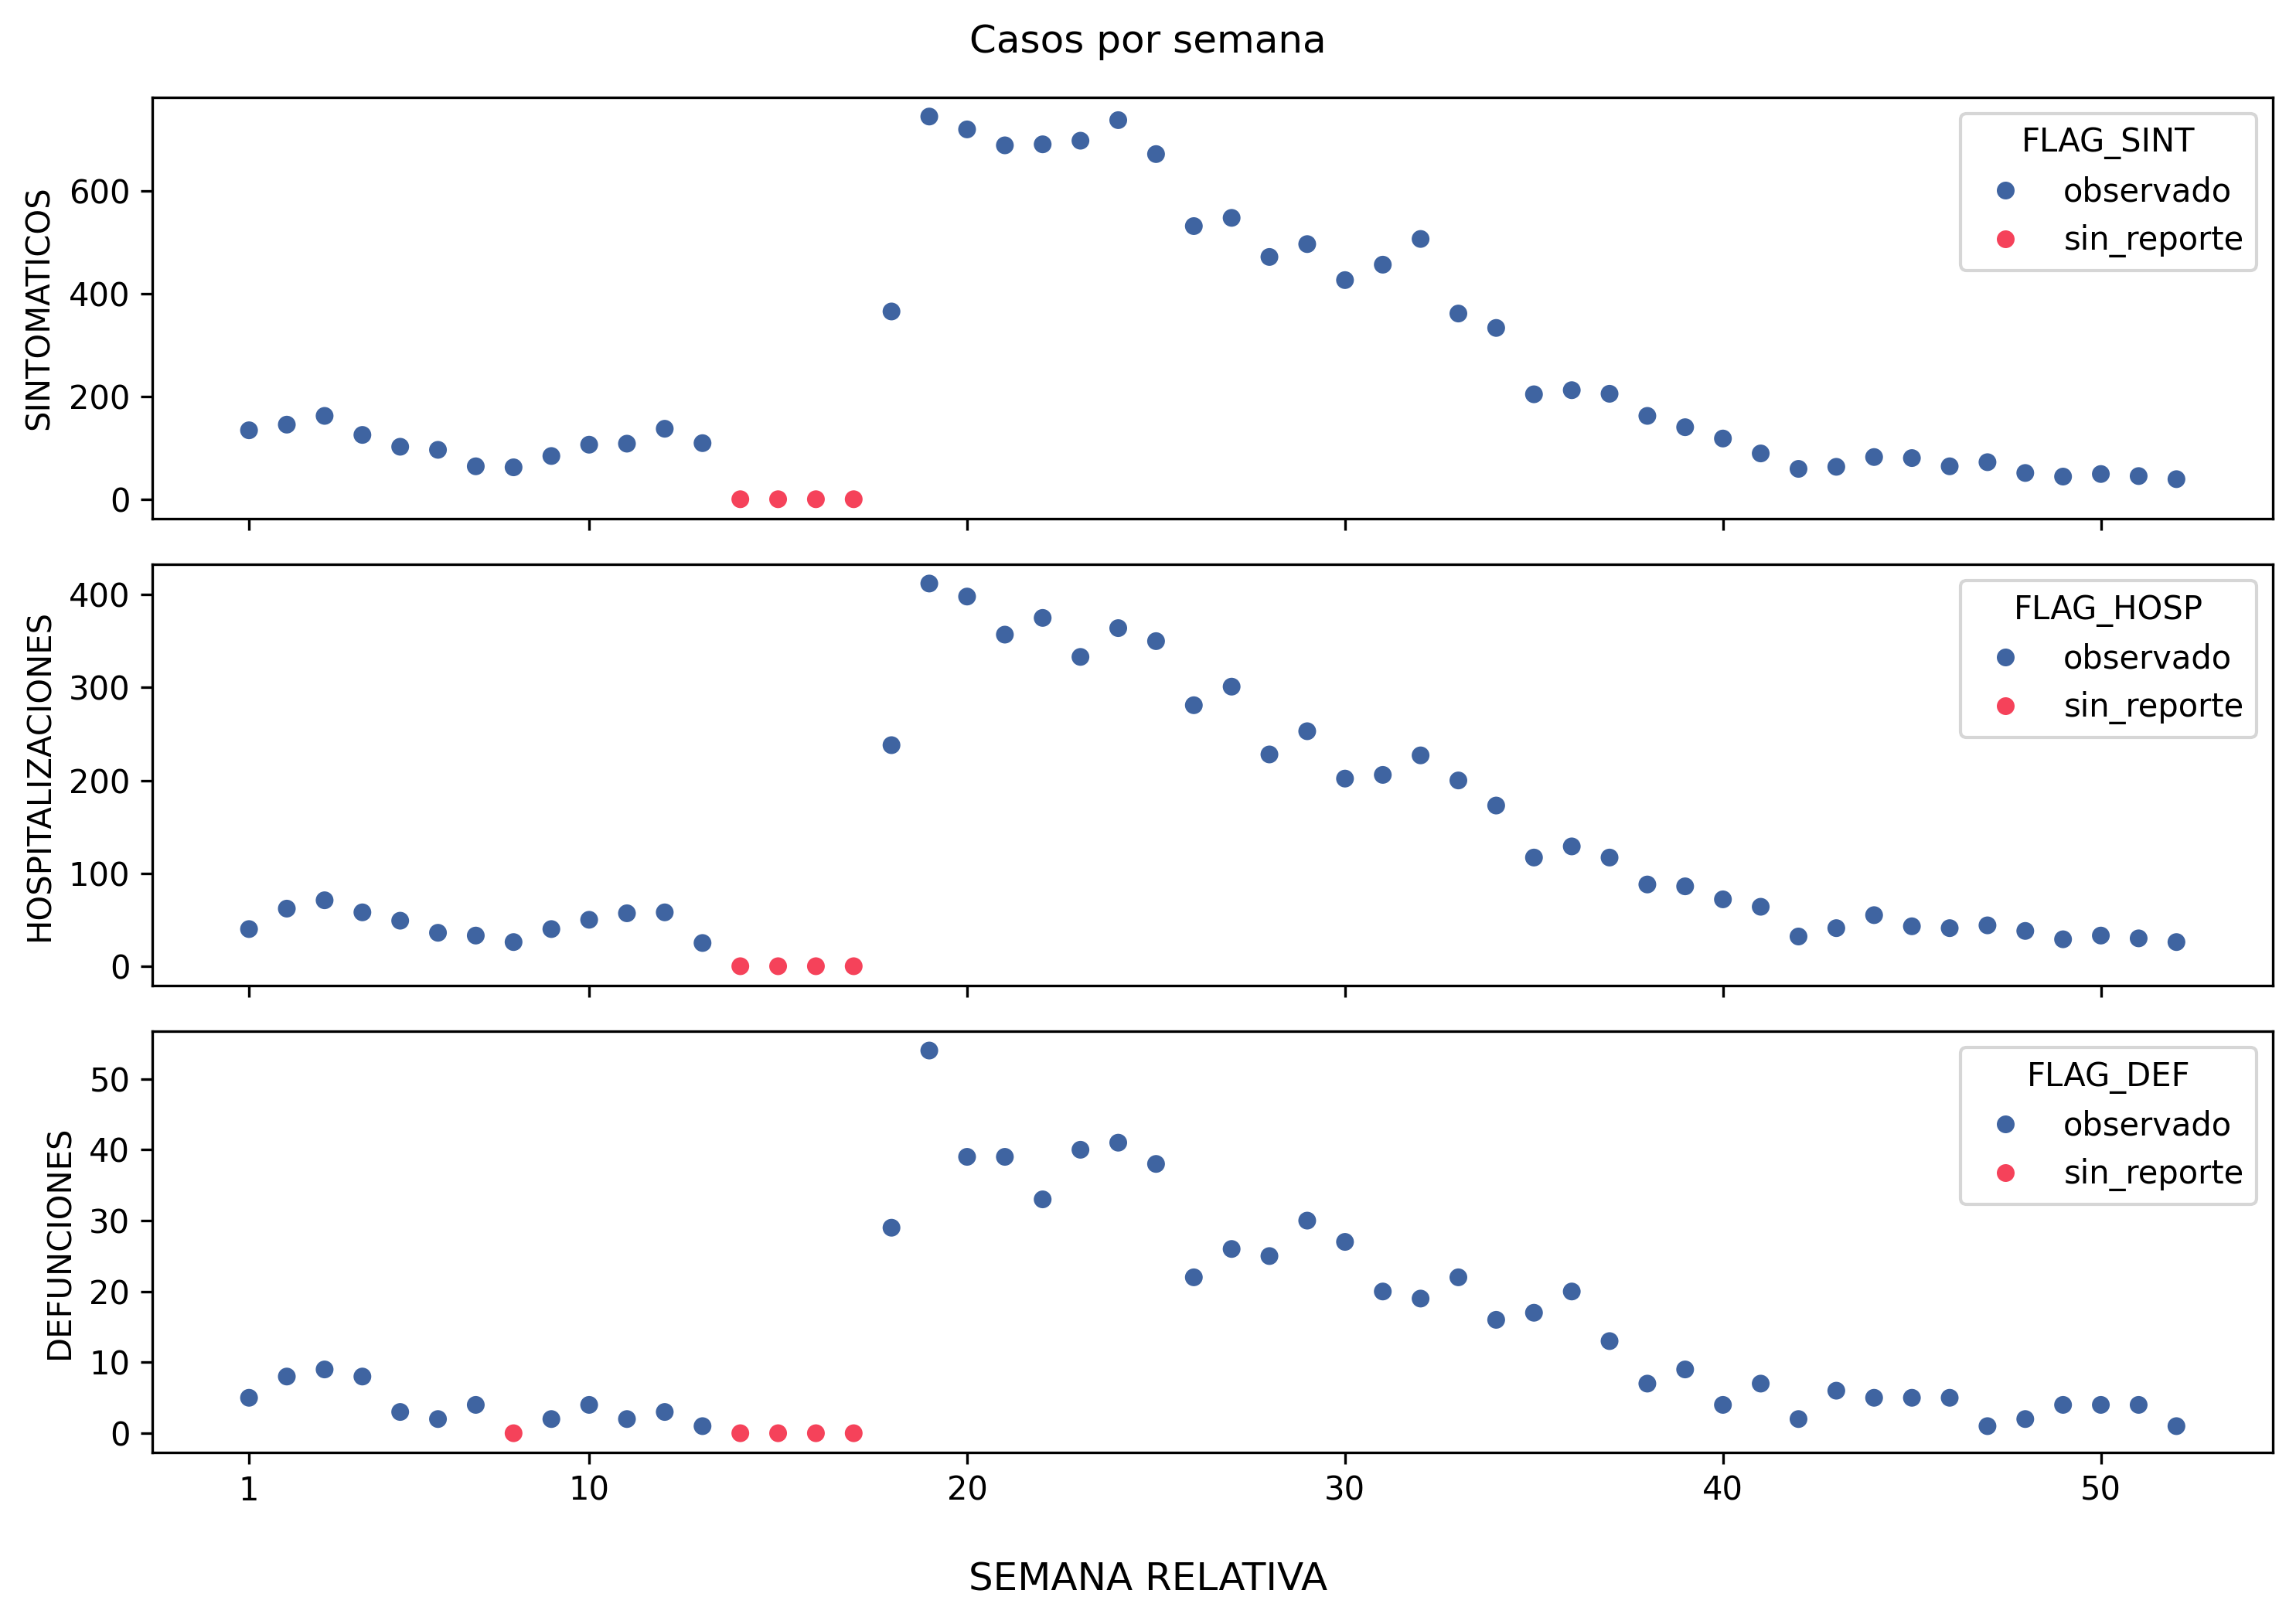

In [4]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(3, figsize = (10,7))
colors = ['#3f64a1', '#f5425a']

casos =  ["SINT", "HOSP", "DEF"]

for i in range(3):
    sns.scatterplot(
        data=influenza, 
        x = "SEMANA_RELATIVA", 
        y = "CASOS_" + casos[i],
        hue = "FLAG_" + casos[i],
        palette = colors,
        ax = ax[i]
    )
    ax[i].set_xticks([1, 10, 20, 30, 40, 50])
    ax[i].set_xlabel(None)
    
fig.supxlabel("SEMANA RELATIVA")

ax[0].set_ylabel("SINTOMATICOS")
ax[1].set_ylabel("HOSPITALIZACIONES")
ax[2].set_ylabel("DEFUNCIONES")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])

fig.suptitle("Casos por semana")
#fig.text(1,1,"HOla")
plt.tight_layout()
plt.show()

## a) Preprocesamiento

### Semanas con datos faltantes o no reportados

In [5]:
# Filtramos aquellas semanas para las cuales una de las "FLAGS" aparece como no_reportado
NoReportes = influenza[(influenza["FLAG_SINT"] == "sin_reporte") | 
                       (influenza["FLAG_HOSP"] == "sin_reporte") |
                       (influenza["FLAG_DEF"] == "sin_reporte")
]
def resaltar_sin_reporte(val):
    color = 'cyan' if val == 'sin_reporte' else ''
    return f'background-color: {color}'

estilo_tabla = (
    NoReportes.style
    .hide(axis='index')
    .set_caption("Semanas con al menos uno de los casos etiquetados como sin_reporte")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
)
estilo_tabla

SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF
8,62,26,0,observado,observado,sin_reporte
14,0,0,0,sin_reporte,sin_reporte,sin_reporte
15,0,0,0,sin_reporte,sin_reporte,sin_reporte
16,0,0,0,sin_reporte,sin_reporte,sin_reporte
17,0,0,0,sin_reporte,sin_reporte,sin_reporte


## b) Modelo 1 - Interpolación

Interpolaremos los datos utilizando un **spline cubico de Hermite**.
Para ello emplearemos la función `PchipInterpolator` de la libreria `SciPy`

**Notas** 

**i)** Para los modelos 1 y 2, la interpolación (y regresión) se realizara en los puntos $x_i=i-\text{iésima semana relativa tal que hay casos observados}$. Por lo tanto el intervalo de los datos será $I=[1, 52]$. Luego cada subintervalo $[i, i+1],\ 1\le i\le 1$ se subdividira en 7 intervalos igualmente espaciados en los cuales se realizaran las predicciones, del modelo correspondiente, dandonos su curva de interpolación o de regresión.

**ii)** En cada caso se agregara al dataset una columna adicional con el valor retornado por cada modelo, para cada uno de los casos (SINT, HOSP, DEF) tanto para los etiquetados como observado, como para los etiquetados como sin_reporte.

**iii)** En cada caso las predicciones de los modelos se han redondeado a un entero. Esto para ser consistente con una cantidad entera de casos por día.

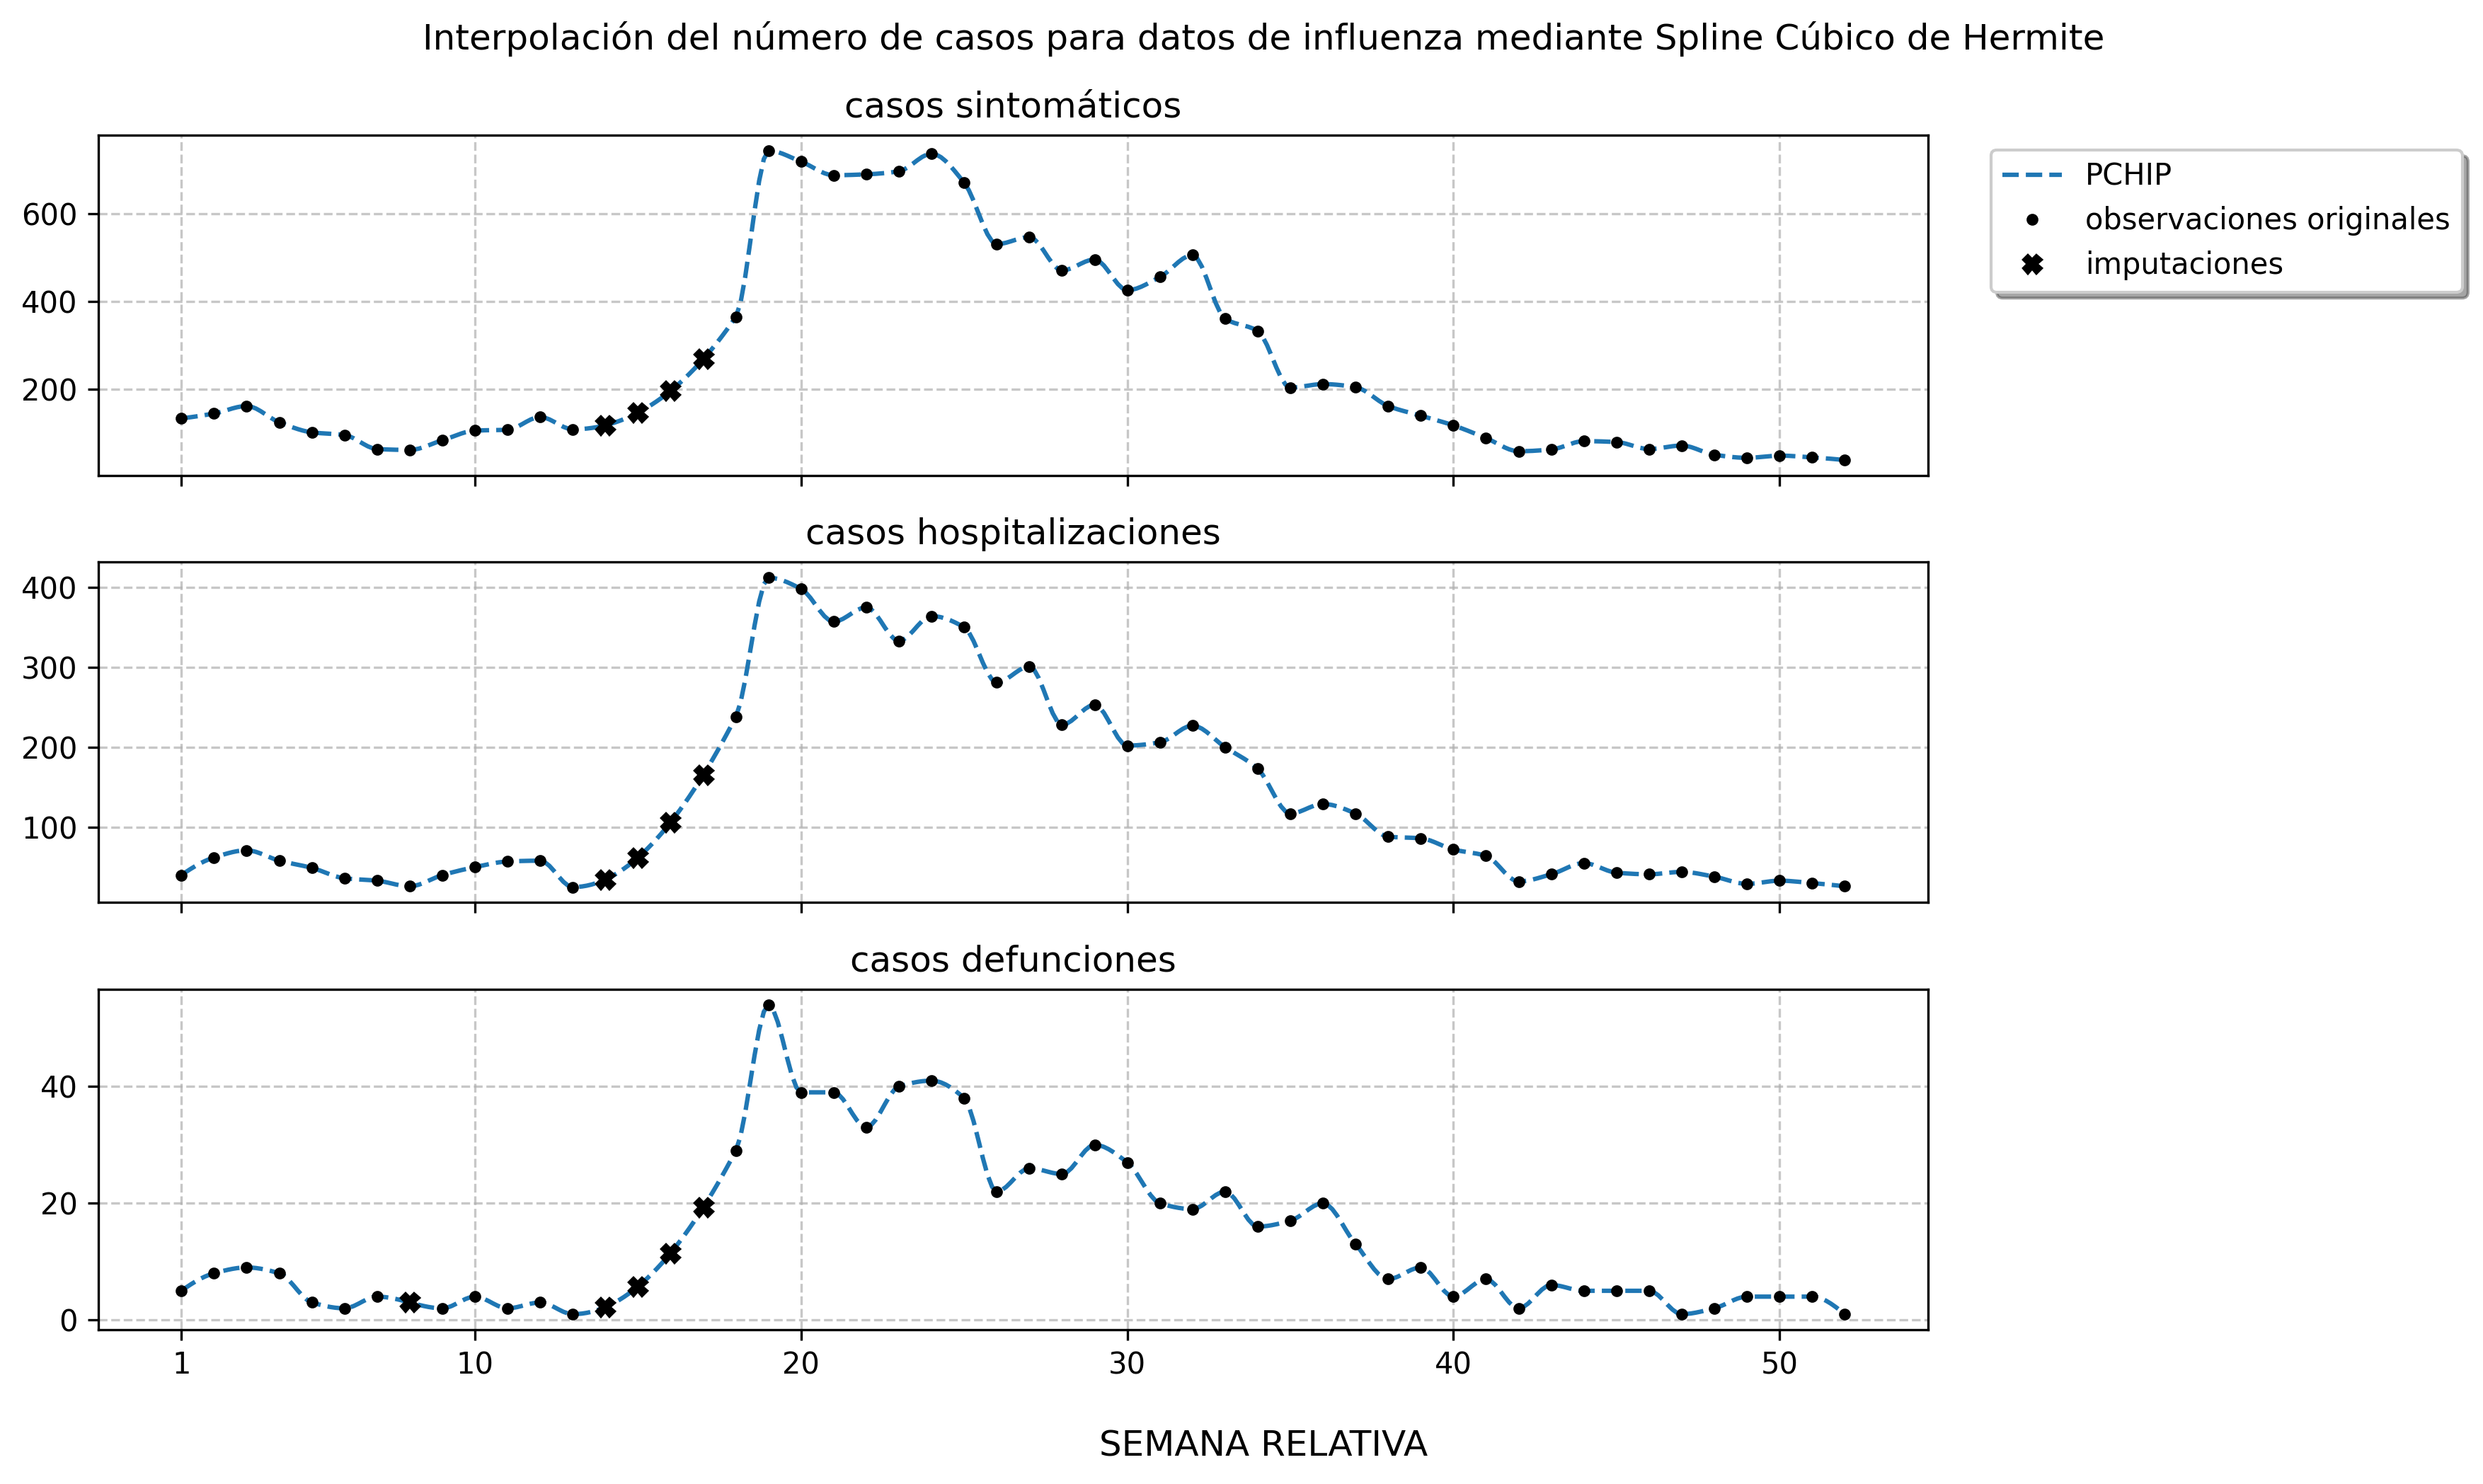

In [6]:
fig, ax = plt.subplots(3, figsize = (12,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["casos sintomáticos", "casos hospitalizaciones", "casos defunciones"]

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]

    PCHIP = PchipInterpolator(SemanasConReporte, CasosObservados)
    X = np.linspace(1, 52, 7*51+1)
    Y = PCHIP(X)
    Imputaciones = PCHIP(SemanasSinReporte)

    ax[i].plot(X, Y, '--', label = "PCHIP", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Imputaciones, 'kX', label='imputaciones')
    
    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])
    ax[i].set_xticks([1, 10, 20, 30, 40, 50])
    ax[i].set_xlabel(None)

    influenza["CASOS_" + casos[i] + "_PCHIP"] = np.round(Y[0:7*51+1:7], decimals=0)

fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Interpolación del número de casos para datos de influenza mediante Spline Cúbico de Hermite")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[0].legend(loc='upper right', fancybox=True, ncols=1, shadow=True, bbox_to_anchor=(1.3,1))
plt.tight_layout()
plt.show() 

## c) Modelo 2 - Regresión Generalizada

Utilizamos un suavizamiento de la serie de tiempo mediante una regresión robusta local ponderada (LOWESS). Para ello emplearemos la función `lowess` de la libreria `statsmodels`.

Este metodo pondera los datos realizando una predicción en el punto $x_i$ de la serie tomando en consideración solo los primeros $rN-{ésimos}$ vecinos a la derecha de $x_i$, en donde

- $N$ es el tamaño de los datos.
- $0<r\le1$ correspond a la fraccion de los datos sobre los que qureremos ponderar respecto a cada $x_i$.
- 
El valor de  $r$ se escoge segun sea conveniente, por ejemplo, disminuyendo los valores residuales. Para este caso utilizaremos el valor de $r=0.5$ como deafault, lo cual corresponde a ponderar sobre la mitad de los datos.

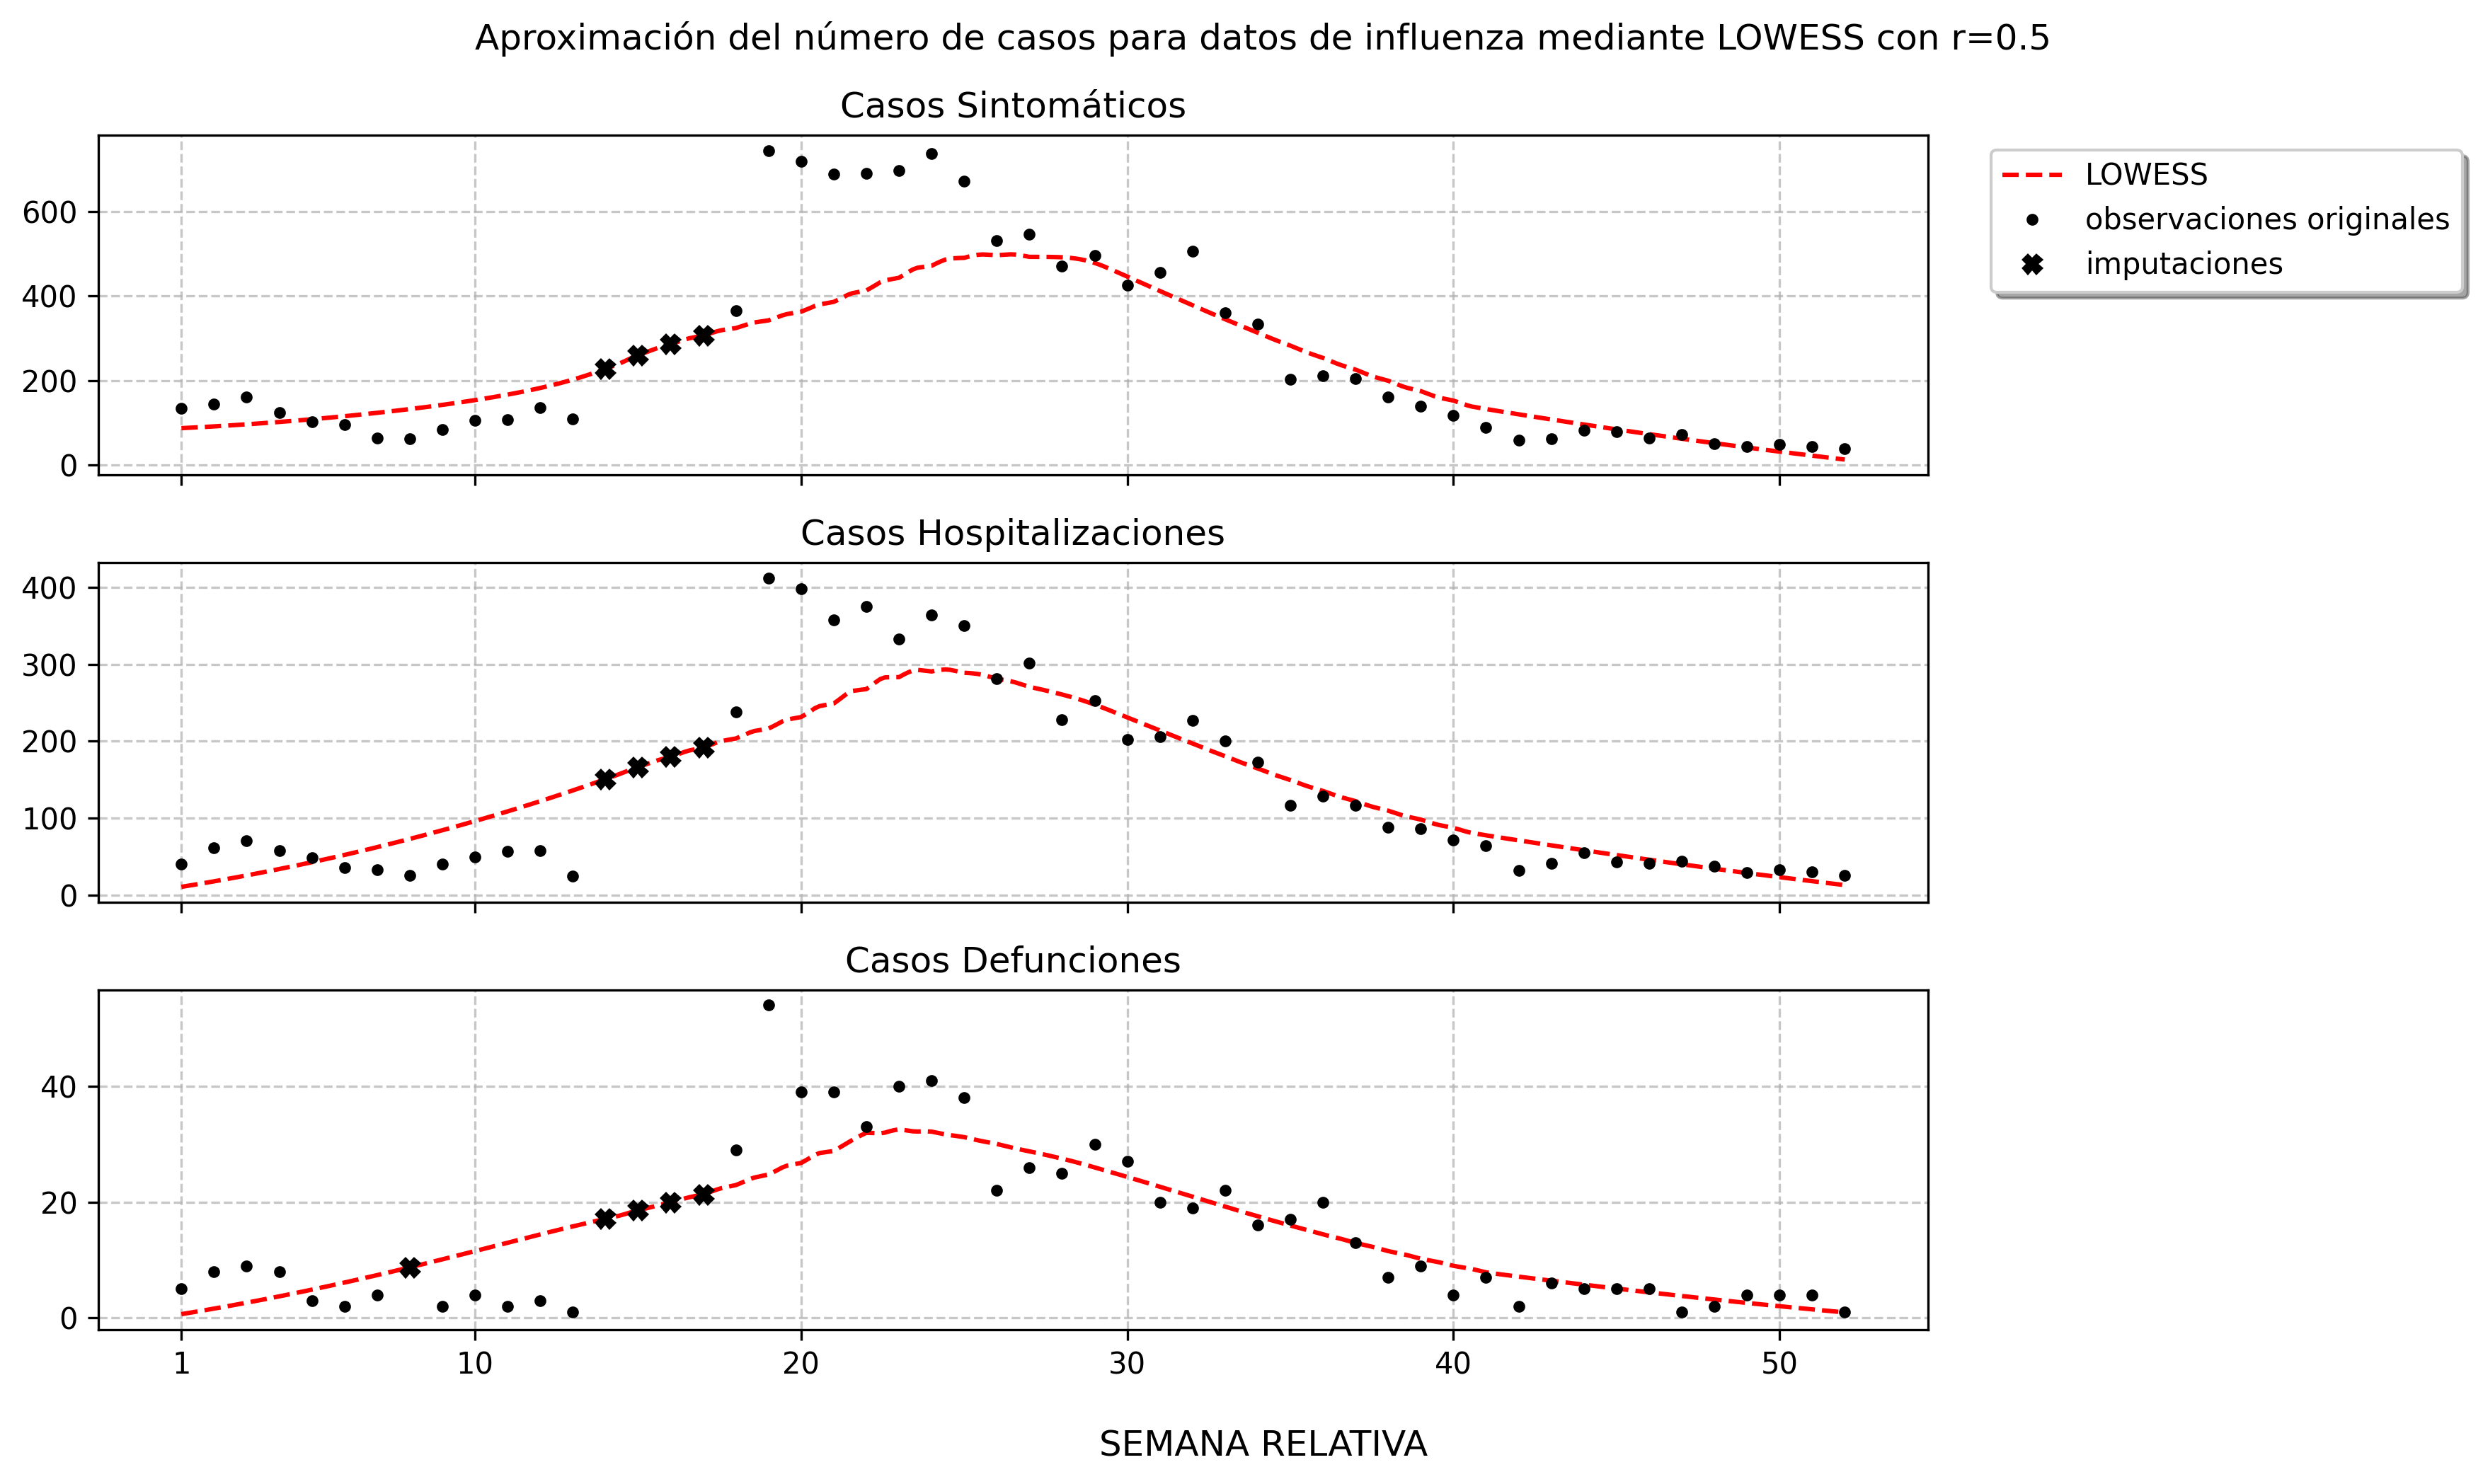

In [7]:
fig, ax = plt.subplots(3, figsize = (12,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["Casos Sintomáticos", "Casos Hospitalizaciones", "Casos Defunciones"]
ErrorModelos = {caso:[0.0] for caso in casos}

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]
    
    X = np.linspace(1, 52, 7*51+1)

    Regression = lowess(CasosObservados, SemanasConReporte,  xvals=X, frac=0.5)

    ax[i].plot(X, Regression, 'r--', label = "LOWESS", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Regression[7*SemanasSinReporte.index], 'kX', label='imputaciones')

    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])
    ax[i].set_xticks([1, 10, 20, 30, 40, 50])

    # Cálculo del error cuadrático
    ErroresCuadraticos = (CasosObservados[SemanasConReporte.index] - Regression[7*SemanasConReporte.index]) ** 2
    PromedioErrores = np.mean(ErroresCuadraticos)
    RMSE = np.sqrt(PromedioErrores)
    ErrorModelos[casos[i]].insert(0, RMSE)

    influenza["CASOS_" + casos[i] + "_LOWESS"] = np.round(Regression[0:7*51+1:7], decimals=0)


ax[0].set_xticklabels([])
ax[1].set_xticklabels([])

fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Aproximación del número de casos para datos de influenza mediante LOWESS con r=0.5")
ax[0].legend(loc='upper right', fancybox=True, ncols=1, shadow=True, bbox_to_anchor=(1.3,1))

plt.tight_layout()
plt.show()

## d) Errores de Estimación

Dado que nos interesa saber que tan bien se ajusta la interpolación y la regresión a nuestros datos observados, conviene saber que tan dispersos estan de la curva obtenida. Por lo que utilizaremos la Raiz del Error Cuadrático Medio (**RMSE**)
$$
\sqrt{\frac{1}{n}\sum\left(\hat{y}_i-y_i\right)^2}
$$
La cual nos da la desvación estandar de los valores residuales.  Notemos que en el caso del Modelo 1, que consistio en interpolar los datos, el **RMSE** es 0 en este caso, pues por la naturaleza del modelo, nos interesa que el modelo coincida con los valores observados en los puntos correspondientes cada semana.

In [8]:
df = pd.DataFrame(ErrorModelos)
df.index = ["LOWESS","PCHIP"]
estilo_tabla = (
    df.style
    .set_caption("RMSE para los modelos 1 y 2")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
    .format(precision=2)
)

estilo_tabla


,SINT,HOSP,DEF
LOWESS,121.58,54.62,7.03
PCHIP,0.00,0.00,0.00


Vemos entonces que por diseño del modelo, PCHIP es quien no solo aproxima mejor los datos, sino que los interpola, en este sentido, nuestro modelo esta aprendiendo los datos, lo cual podría no ser la mejor opción si nuestro interes es predecir un aproximado del número de casos para las semanas sin reportes. LOWESS es entonces una opción más adecuada, pues aprende mejor las tendencias de la serie temporal.

## e) Totales y comparación

Calcularemos el total acumulado de hospitalizaciones y defunciones.

In [9]:
modelos = ["PCHIP", "LOWESS"]
casos =  ["HOSP", "DEF"]
index = ["Hospitalizaciones", "Defunciones"]

CasosAcumulados = {"Datos Originales":[], "PCHIP":[], "LOWESS":[]}

for caso in casos:
    N = influenza["CASOS_" + caso].sum()
    CasosAcumulados["Datos Originales"].append(N)


for modelo in modelos:
    for caso in casos:
        N = influenza["CASOS_" + caso + "_" + modelo].sum()
        CasosAcumulados[modelo].append(N)

CasosAcumulados = pd.DataFrame(CasosAcumulados)
CasosAcumulados.index = casos

estilo_tabla = (
    CasosAcumulados.style
    .set_caption("Casos totales acumulados para los diferentes modelos y casos")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
    .format(precision=0)
)


estilo_tabla


,Datos Originales,PCHIP,LOWESS
HOSP,6588,6955,6865
DEF,687,728,753


Comparando los datos podemos notar que el modelo PCHIP predice más hospitalizaciones respecto al modelos LOWESS.
Por otra parte, el modelo LOWESS predice mayor número de defunciones respecto al modelo PCHIP

# Bonus

Crearemos un dataframe llamado `HospAcumuladas` para guardar la serie de hospitalizaciones acumuladas, rellenando con las predicciones del modelo LOWESS.

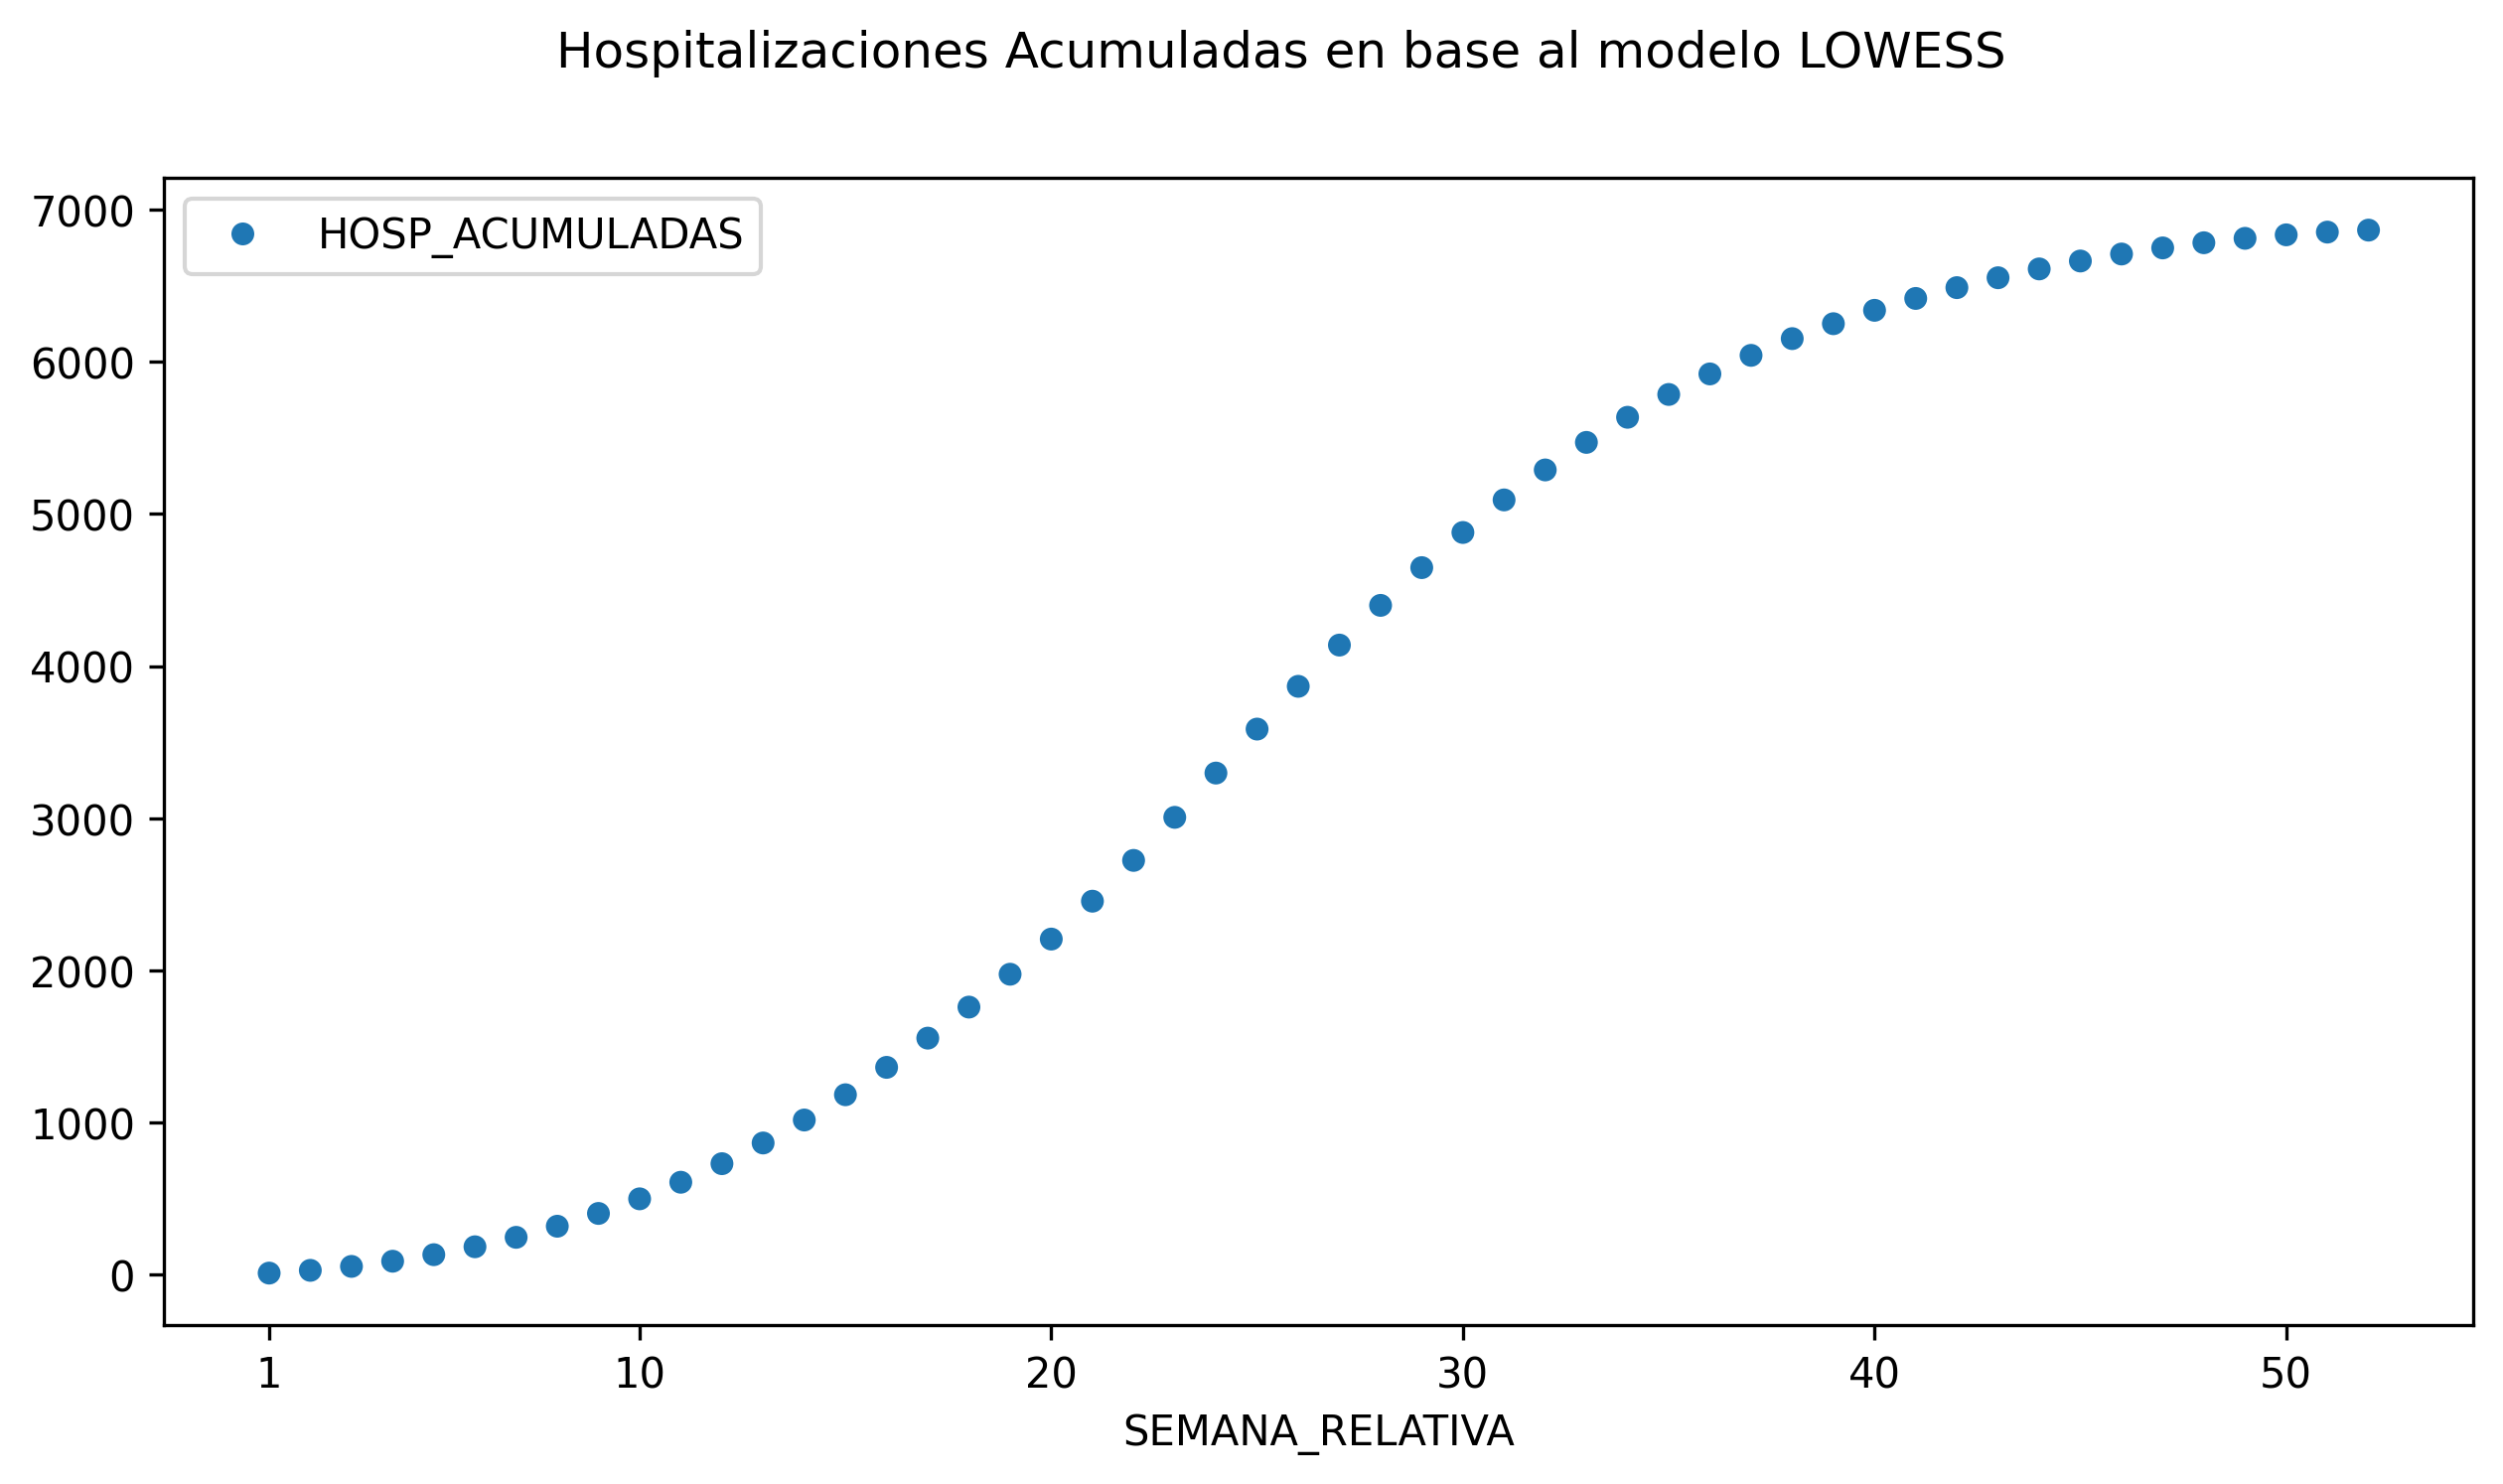

In [10]:
HospAcumuladas = influenza[["CASOS_HOSP_LOWESS"]].cumsum()
HospAcumuladas = HospAcumuladas.rename(columns={"CASOS_HOSP_LOWESS": "HOSP_ACUMULADAS"})
HospAcumuladas.index = influenza["SEMANA_RELATIVA"]


fig, ax = plt.subplots(figsize = (10,5))
colors = ['#3f64a1', '#f5425a']

sns.scatterplot(
    data=HospAcumuladas, 
    x = "SEMANA_RELATIVA", 
    ax = ax
    )
ax.set_xticks([1, 10, 20, 30, 40, 50])
sns.scatterplot(HospAcumuladas)
fig.suptitle("Hospitalizaciones Acumuladas en base al modelo LOWESS")
plt.show()

## B1) Ajuste del modelo acumulado

Aproximaremos la serie de tiempo mediante una curva logistica
$$
F(t;K,r,t_0) = \frac{K}{1+e^{-r(t-t_0)}}
$$
en donde $t$ es un punto en el tiempo, $K$ es la capacidad máxima, $r$ la tasa de crecimiento, y $t_0$ el punto de inflexión.

Nuestro objetivo es aproximar aquellos valores de $K,\ r$ y $t_0$ que minimicen el error cuadratico entre las predicciones y los datos observados. Para ello emplearemos la función `least_squares` de la libreria `scipy.optimize`.

Representaremos los paramentros como un arreglo $\theta$ en donde

- $\theta(0) = K$
- $\theta(1) = r$
- $\theta(2) = t_0$

La función trabaja a partir de un estimado dado de los parametros, en este casos  utilzaremos las estimaciones
- $K = 7000$ que es un valor moderadamente mayor al total de casos acumulados predichos por LOWESS
- $r = 2$
- $t_0 = 24$ la semana en la que visualmente se tiene el punto de inflexión de los datos.



In [11]:
from scipy.optimize import least_squares

# Defininimos la función de la curva logistica
def F(theta, t):
    return theta[0] / (1 + np.exp(- theta[1] * (t - theta[2])))

# Declaramos los puntos de la serie de tiempo, la semanas relativas en en este caso
ts = np.array(HospAcumuladas.index)
ys = np.array(HospAcumuladas["HOSP_ACUMULADAS"])

# Definimos nuestra función de costo o de valores residuales
def residuales(theta):
    return F(theta, ts) - ys

theta = [7000, 2, 24]
res = least_squares(residuales, theta)

# Imprimimos los parametros obtenidos
print("Los parametros obtenidos son:")
print(f"K = {res.x[0]}")
print(f"r = {res.x[1]}")
print(f"t_0 = {res.x[2]}")

Los parametros obtenidos son:
K = 6872.716122052255
r = 0.166657706798571
t_0 = 24.60893448341319


Redondearemos los parametros de manera que 
 - $K = 6872$
 - $r = 0.17$
 - $t_0 = 24.61$ 

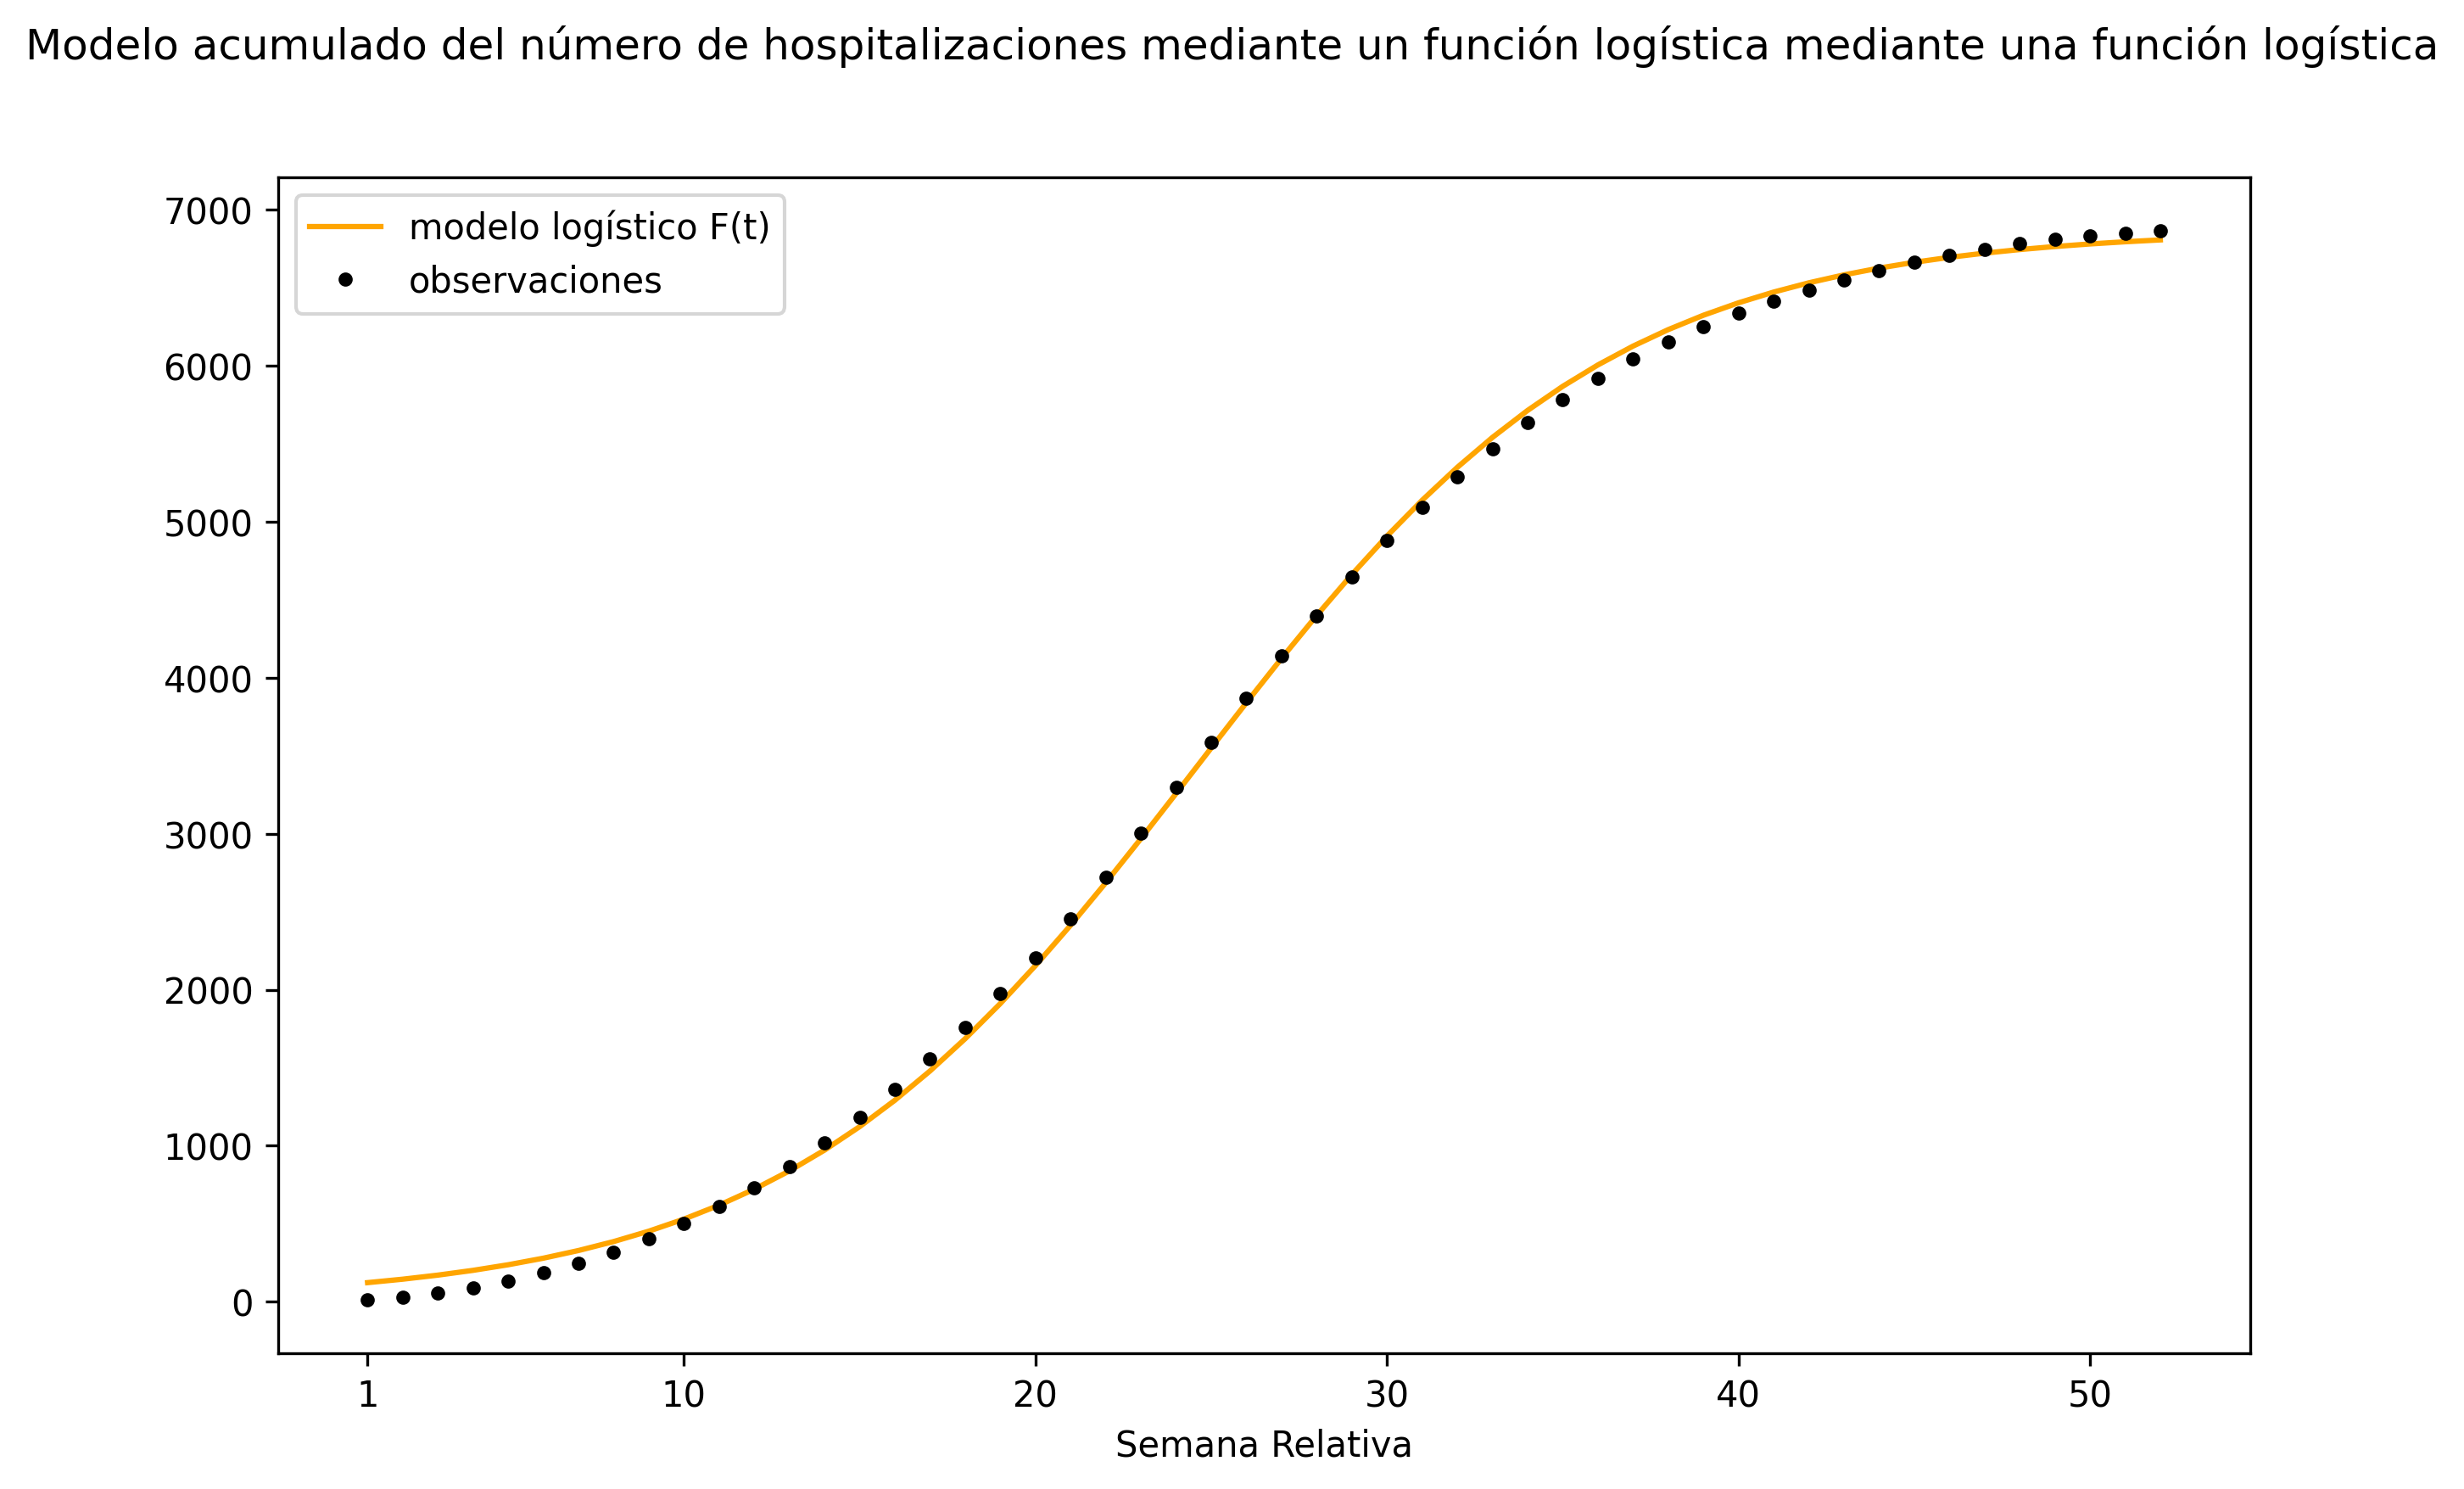

In [12]:
fig, ax = plt.subplots(figsize = (10,6))

K = 6872
r = 0.17
t0 = 24.61
theta = [K, r, t0]

# Calculamos los valores predichos por la curva logística obtenida
Y = [F(theta, t) for t in ts]
ax.plot(ts, Y, '-', color='orange', label="modelo logístico F(t)")
ax.plot(ts, ys, 'k.', label="observaciones")

ax.set_xticks([1, 10, 20, 30, 40, 50])
ax.set_xlabel("Semana Relativa")
fig.suptitle("Modelo acumulado del número de hospitalizaciones mediante un función logística mediante una función logística")
plt.legend()
plt.show()

Tenemos segun lo anterior que la curva logística esta dada por
$$
F(t) = \frac{6872}{1+e^{-0.17(t-24.61)}}
$$

Graficaremos ahora los valores residuales

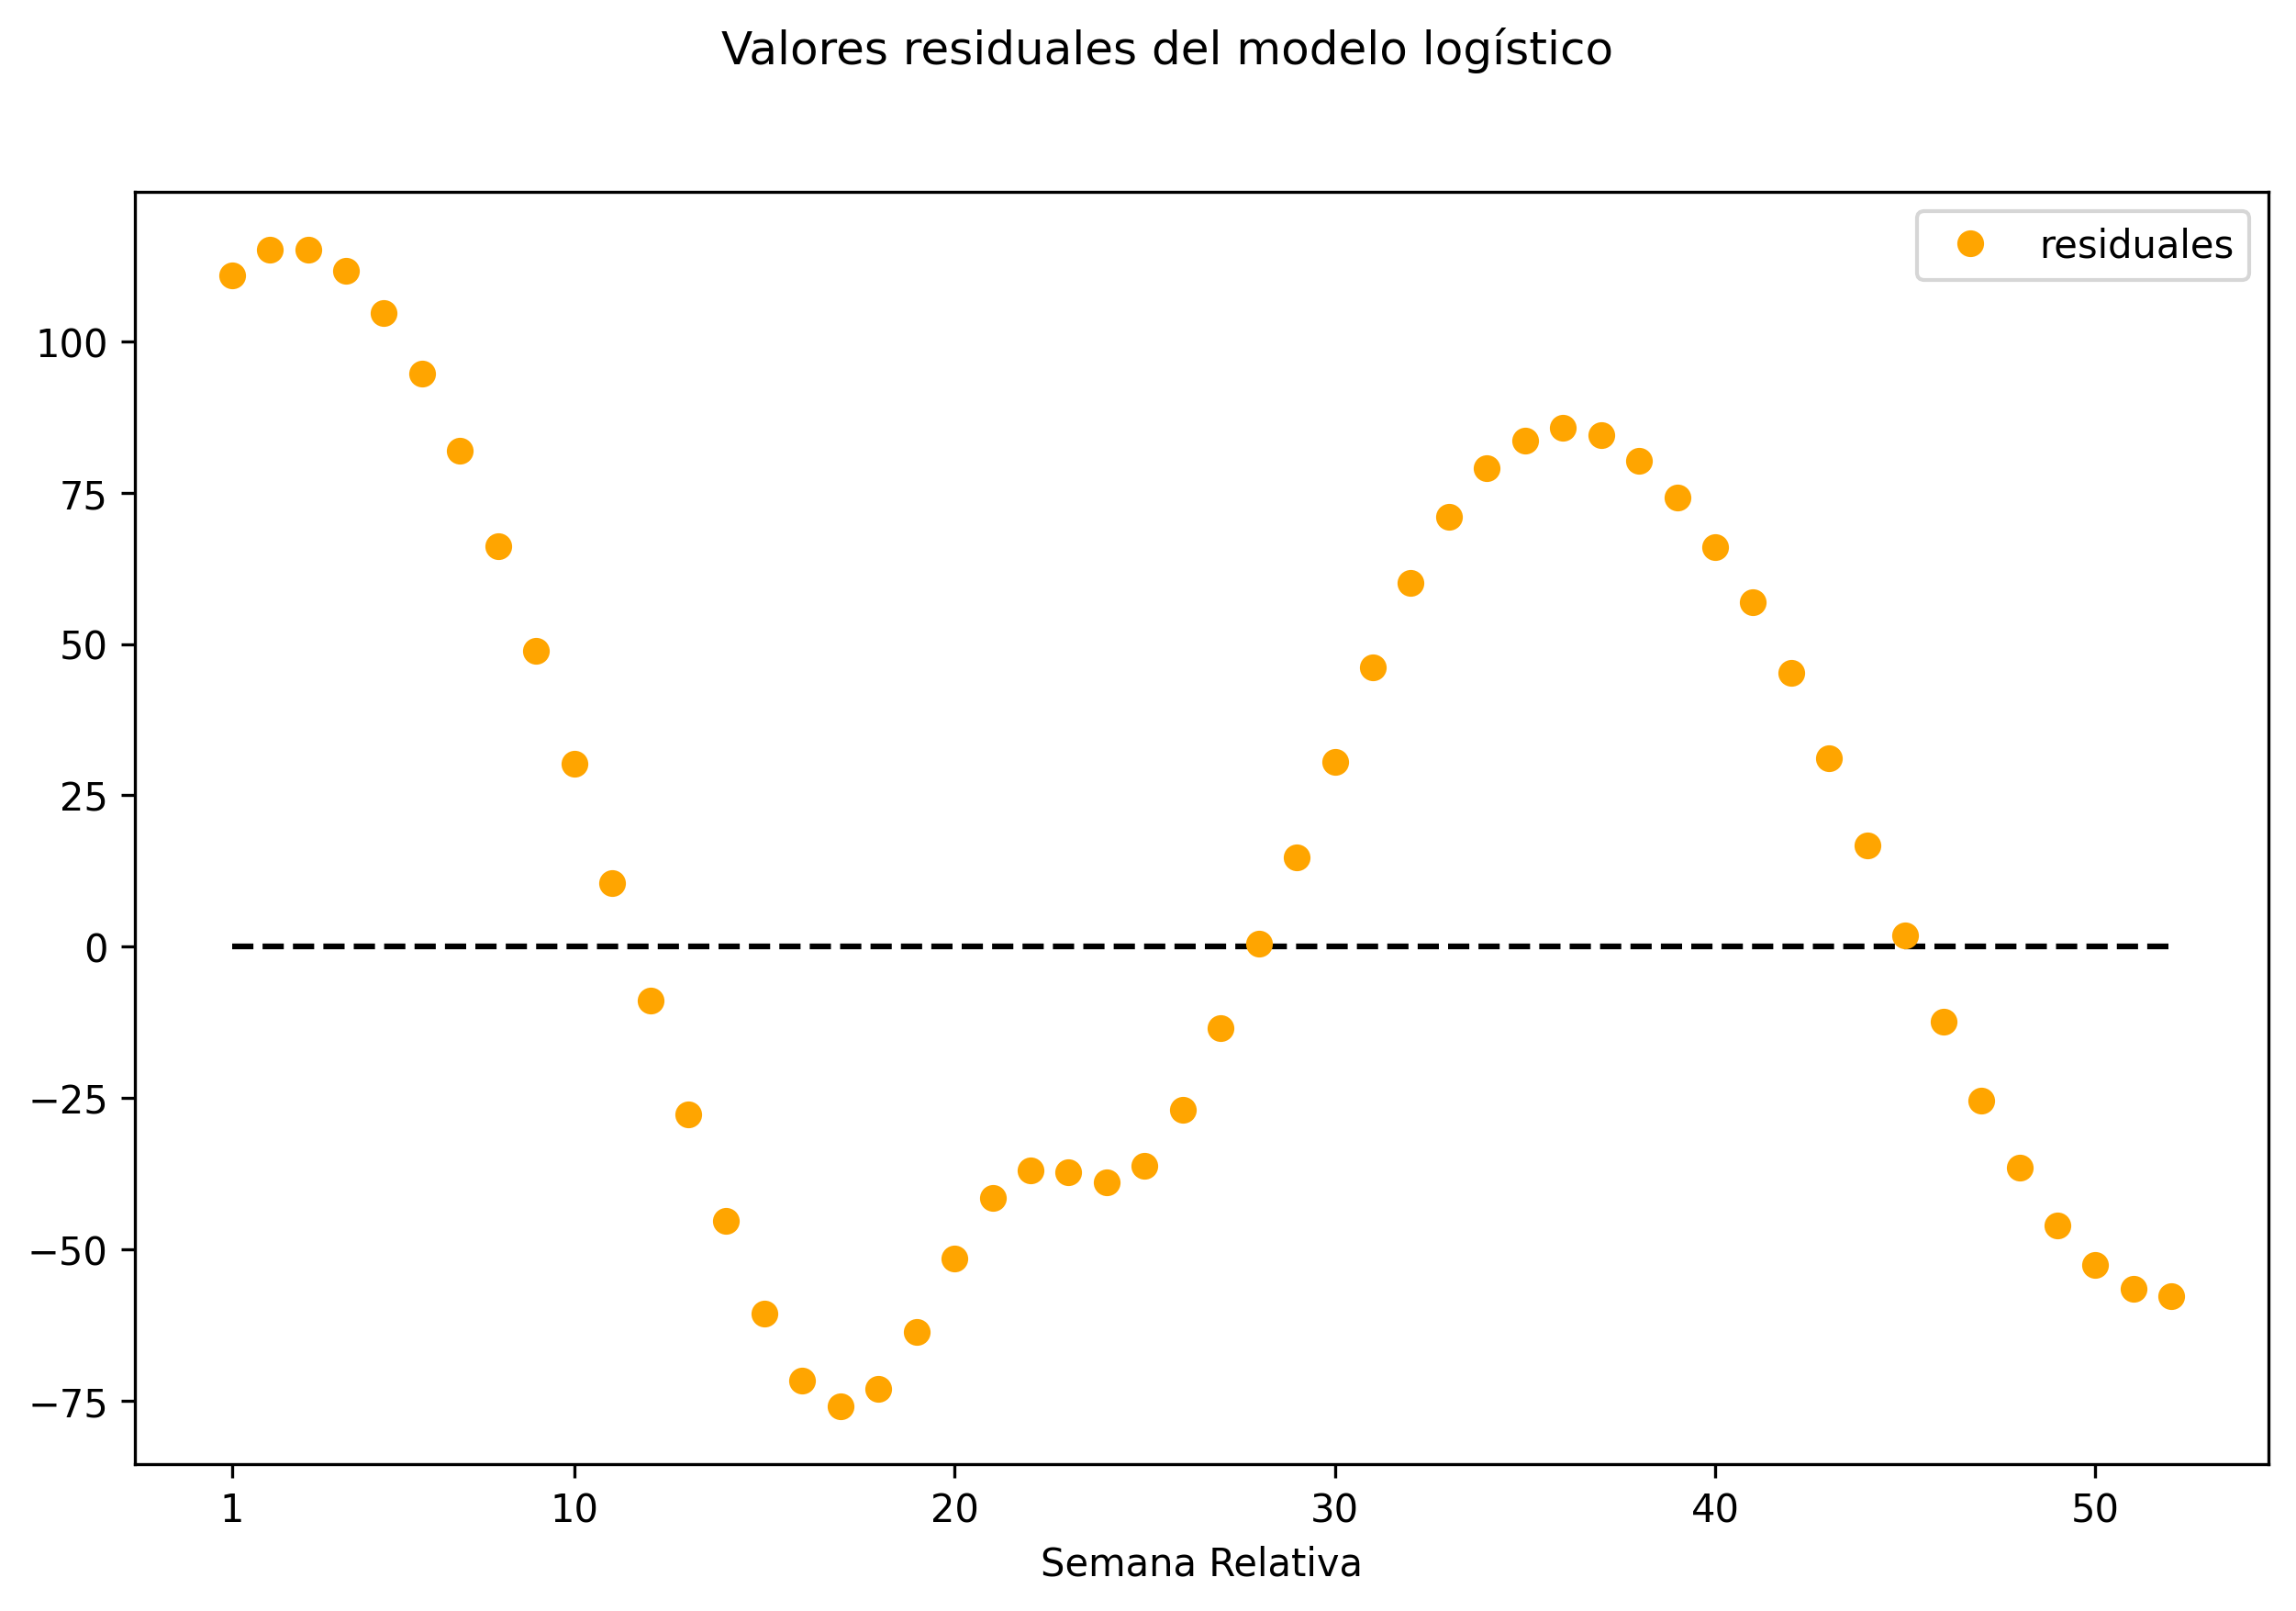

In [13]:
fig, ax = plt.subplots(figsize = (10,6))

ax.hlines(0, 1, 52, linestyles='dashed', color='black')
ax.plot(ts, residuales(theta), 'o', color='orange', label="residuales")

ax.set_xticks([1, 10, 20, 30, 40, 50])
ax.set_xlabel("Semana Relativa")
fig.suptitle("Valores residuales del modelo logístico")
plt.legend()
plt.show()


## B2) Algoritmo de detección temprana del pico epidémico

Recordemos que

 - $K = 6872$
 - $r = 0.17$
 - $t_0 = 24.61$ 

### i) Estimación de $f'(t)=F'(t)$

Derivando directamente llegamos a que
$$
f(t)=F'(t) = rK\frac{e^{-r(t-to)}}{(1+e^{-r(t-to)})^2}
$$

Haciendo 
$$
p = \frac{K}{1+e^{-r(t-t_0)}}
$$
tenemos que
$$
e^{-r(t-t_0)}=\frac{K}{p}-1
$$
luego
$$
-r(t-t_0)=\ln{\left(\frac{K}{p}-1\right)}
$$
finalmente
$$
Q(p)=F^{-1}(p)=-\frac{1}{r}\ln{\left(\frac{K}{p}-1\right)}+t_0=t
$$

Implementando estas funciones a codigo se tiene que

In [14]:
def f(theta, t):
    exponent = - theta[1] * (t - theta[2])
    exp_val = np.exp(exponent)
    resultado = theta[1] * theta[0] * (exp_val / (1 + exp_val)**2)
    return resultado

def Q(theta, p):
    return (-1 / theta[1]) * np.log((theta[0] / p) - 1) + theta[2]
    

In [15]:
F(theta,1)

np.float64(121.94928926262486)

In [16]:
ys[0]

np.float64(11.0)

Podemos entonces definir 
$$
Q(p)=F^{-1}(p) \quad p\in[122, K)
$$
el intervalo empieza en 121 ya que es el redondeado del número de casos predicho por el modelo logístico durante la primera semana.

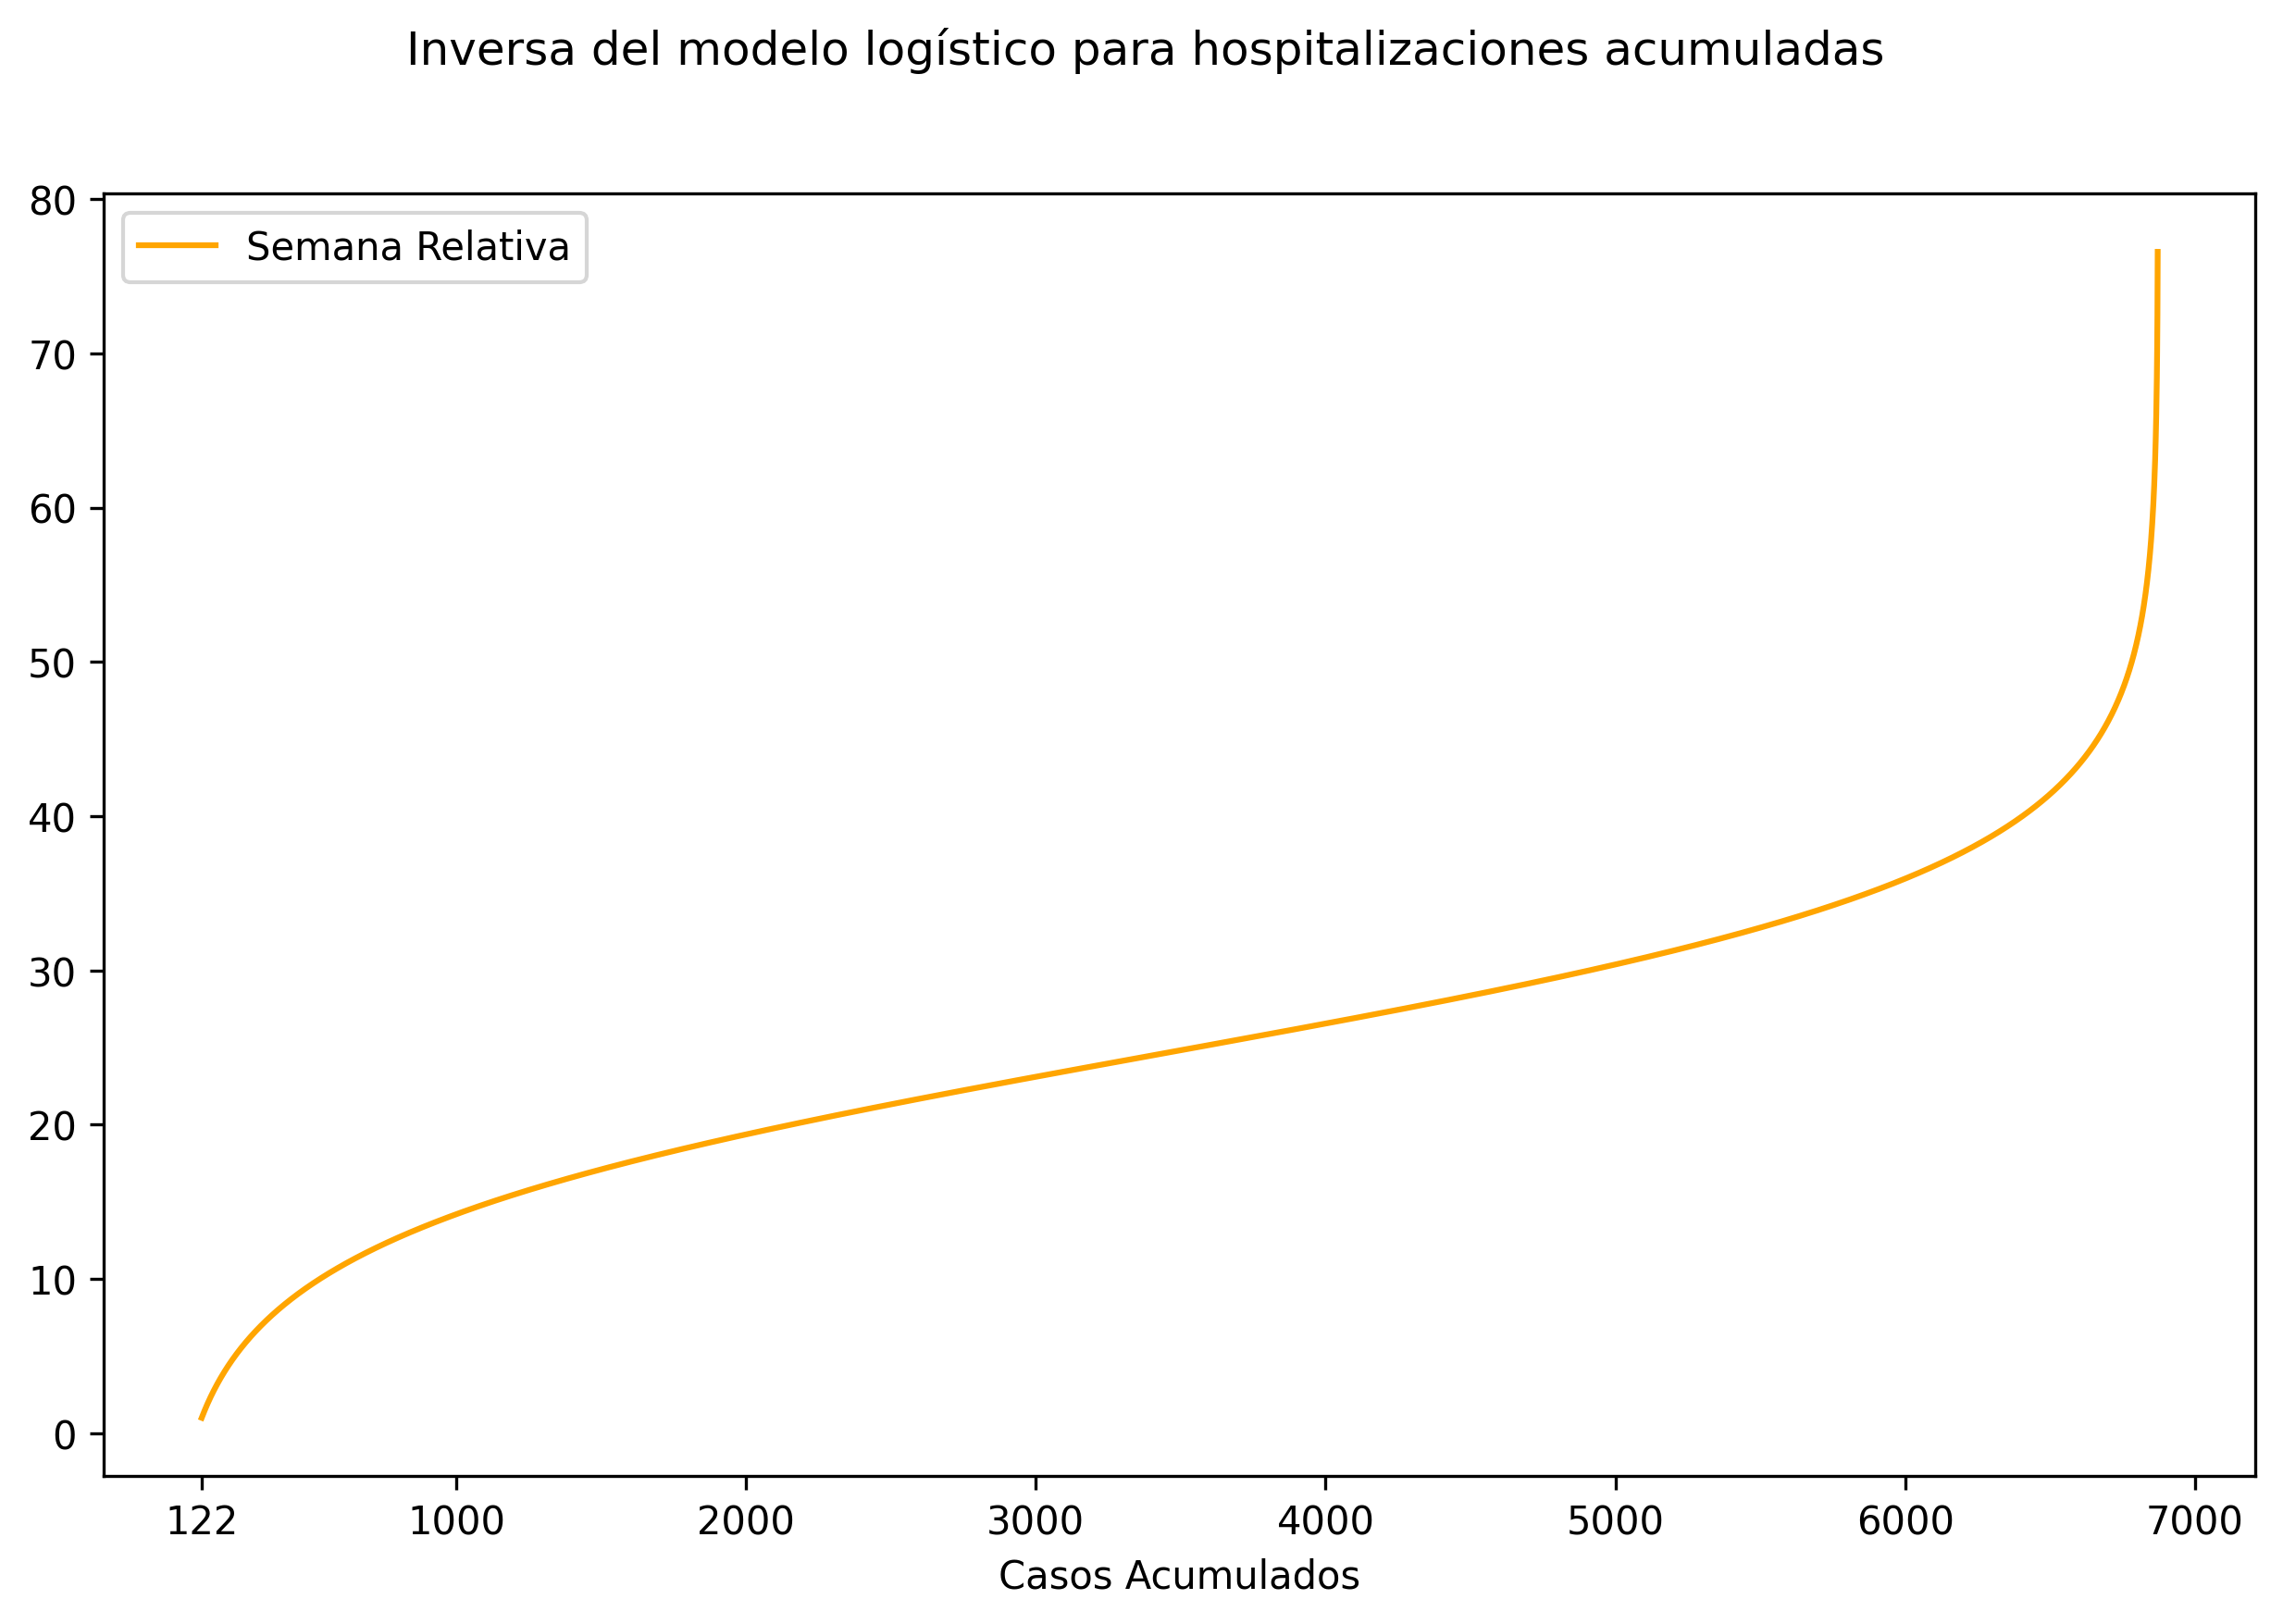

In [17]:
fig, ax = plt.subplots(figsize = (10,6))

P = np.arange(122, K, 1)
Y = [Q(theta, p) for p in P]
ax.plot(P, Y, '-', color='orange', label="Semana Relativa")

ax.set_xticks([122, 1000, 2000, 3000, 4000, 5000, 6000, 7000])
ax.set_xlabel("Casos Acumulados")
fig.suptitle("Inversa del modelo logístico para hospitalizaciones acumuladas")
plt.legend()
plt.show()

### ii) $Q'(p)$ y $Q''(p)$ sobre una malla de valores de p

A partir de los resultados anteriores podemos definir explícitamente quien es $Q'(p)$, y de manera numérica quien es $Q''(p)$.

La malla de valores de $p$ la construiremos tomando unicamente valores enteros para $p$, en el intervalo $(122, K]$ será sobre esta misma malla que estimaremos la segunda derivada de $Q$ empleando la función `derivate` de la libreria `scipy.differentiate`, aplicada a la función `dQ(p)` imeplementada en python, correspondiente a $Q'(p)$.

In [18]:
# defincición de dQ(p) = Q'(p)

def dQ(p):
    return 1 / f(theta, Q(theta, p))

Mostraremos la gráfica de $Q''(x)$ tomando escala logarítmica en el eje $Y$

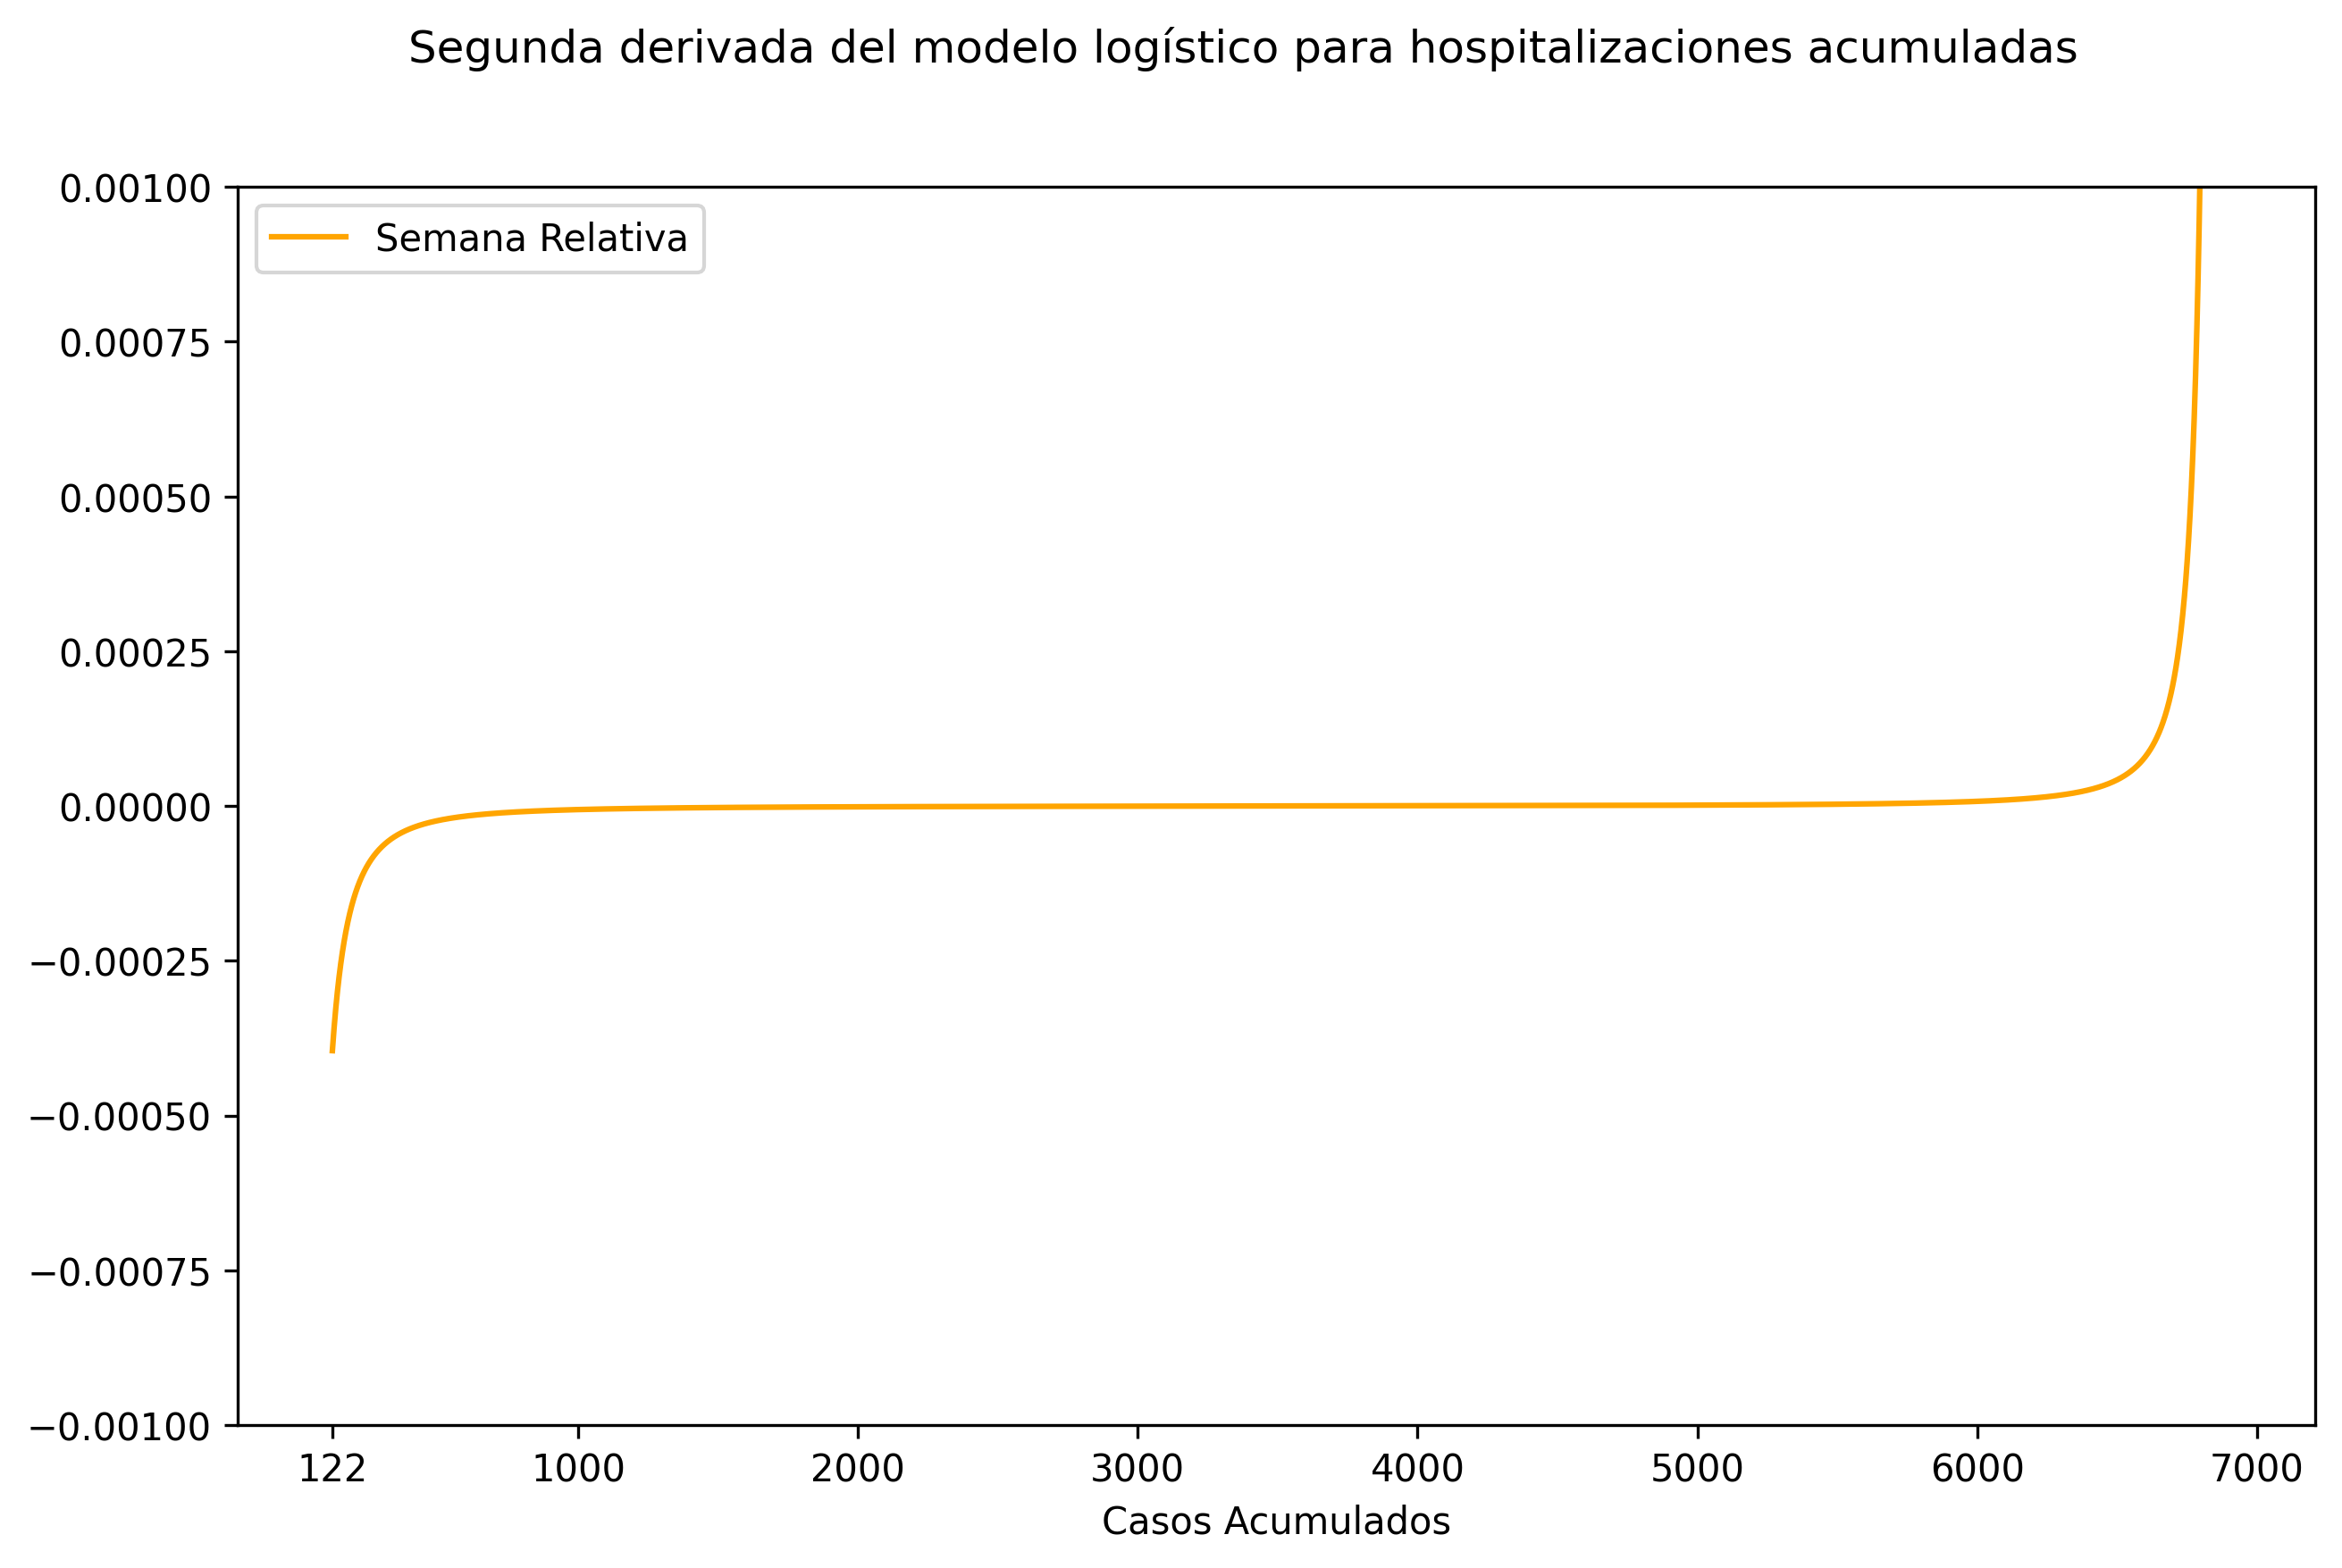

In [27]:
from scipy.differentiate import derivative
# definimos la malla de valores para p

mallaP = np.arange(122, K, 1)

# Calculamos la segunda derivada de Q sobre mallaP
ddQ = derivative(dQ, mallaP)

fig, ax = plt.subplots(figsize = (10,6))

ax.plot(mallaP, ddQ.df, '-', color='orange', label="Semana Relativa")
ax.set_ylim(-0.001, 0.001)
ax.set_xticks([122, 1000, 2000, 3000, 4000, 5000, 6000, 7000])
ax.set_xlabel("Casos Acumulados")
fig.suptitle("Segunda derivada del modelo logístico para hospitalizaciones acumuladas")
plt.legend()
plt.show()

Parar una mejor visualización del punto de inflexión hemos restringido el eje $Y$ al intervalo $[-10^{-3},10^3]$.

### iii) Primera inflexión del modelo logístico

 Podemos ahora iterar sobre la malla de $p$ e identificar el momento justo antes del punto de inflexión

In [37]:
p_inflexion = 0
for i in range (len(ddQ.df)):
    if ddQ.df[i+1] > 0 :
        p_inflexion = i + 122
        break

print(f"La primera inflexión se da en p = {p_inflexion}")

La primera inflexión se da en p = 3436


Tenemos entonces que para una cantidad acumulada de hospitalizaciones de $p^\ast=3436$ se da la primera inflexión.

### iv) De regreso a la escala temporal

Aplicando $F^{-1}$, y redondeando al entero más cercano obtenemos que 

In [41]:
print(f"t_inflexión = {Q(theta, p_inflexion)}")

t_inflexión = 24.61


La semana de inicio del pico corresponde a $t^{\ast}=F^{-1}(p)\approx 24$.

#### v) Gráfica del inicio del pico